# Naive Bayes e classificação de texto

**Tema:** Aprendizado Supervisionado › k-NN e Naive Bayes

Este notebook implementa Naive Bayes Gaussiano do zero a partir do teorema
de Bayes (tema 1), mostra o problema da frequência zero e a correção por
suavização de Laplace, e termina com o caso de uso mais clássico do
modelo: classificação de texto com Multinomial NB.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(13)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Naive Bayes Gaussiano do zero

In [2]:
class NaiveBayesGaussianoDoZero:
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.medias_, self.variancias_, self.priors_ = {}, {}, {}
        for c in self.classes_:
            X_c = X[y == c]
            self.medias_[c] = X_c.mean(axis=0)
            self.variancias_[c] = X_c.var(axis=0) + 1e-9  # evita variância zero
            self.priors_[c] = len(X_c) / len(X)
        return self

    def _log_verossimilhanca_gaussiana(self, X, media, variancia):
        # log da densidade normal, somada sobre as features (independência "naive")
        termo = -0.5 * np.log(2 * np.pi * variancia) - (X - media) ** 2 / (2 * variancia)
        return termo.sum(axis=1)

    def predict_proba(self, X):
        log_posteriores = []
        for c in self.classes_:
            log_verossim = self._log_verossimilhanca_gaussiana(
                X, self.medias_[c], self.variancias_[c])
            log_posteriores.append(log_verossim + np.log(self.priors_[c]))
        log_posteriores = np.array(log_posteriores).T
        # normaliza em espaço log para estabilidade numérica (o mesmo truque
        # do softmax: subtrai o máximo antes de exponenciar)
        log_posteriores -= log_posteriores.max(axis=1, keepdims=True)
        posteriores = np.exp(log_posteriores)
        return posteriores / posteriores.sum(axis=1, keepdims=True)

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


n = 600
X_classe0 = rng.normal([2, 5], [1, 2], (n // 2, 2))
X_classe1 = rng.normal([6, 3], [1.5, 1], (n // 2, 2))
X = np.vstack([X_classe0, X_classe1])
y = np.concatenate([np.zeros(n // 2), np.ones(n // 2)])

modelo_manual = NaiveBayesGaussianoDoZero().fit(X, y)
modelo_sklearn = GaussianNB().fit(X, y)

pred_manual = modelo_manual.predict(X)
pred_sklearn = modelo_sklearn.predict(X)
print(f"concordância entre implementação manual e sklearn: "
      f"{(pred_manual == pred_sklearn).mean():.1%}")

probs_manual = modelo_manual.predict_proba(X)[:5]
probs_sklearn = modelo_sklearn.predict_proba(X)[:5]
print(f"\nprimeiras 5 probabilidades (manual):\n{probs_manual}")
print(f"\nprimeiras 5 probabilidades (sklearn):\n{probs_sklearn}")

concordância entre implementação manual e sklearn: 100.0%

primeiras 5 probabilidades (manual):
[[0.9649 0.0351]
 [0.9832 0.0168]
 [0.9917 0.0083]
 [0.8506 0.1494]
 [0.9999 0.0001]]

primeiras 5 probabilidades (sklearn):
[[0.9649 0.0351]
 [0.9832 0.0168]
 [0.9917 0.0083]
 [0.8506 0.1494]
 [0.9999 0.0001]]


## 2. A suposição de independência: visualizando o que ela ignora

Vamos gerar dados onde as duas features são FORTEMENTE correlacionadas
dentro de cada classe, e ver o quanto isso afeta o modelo.

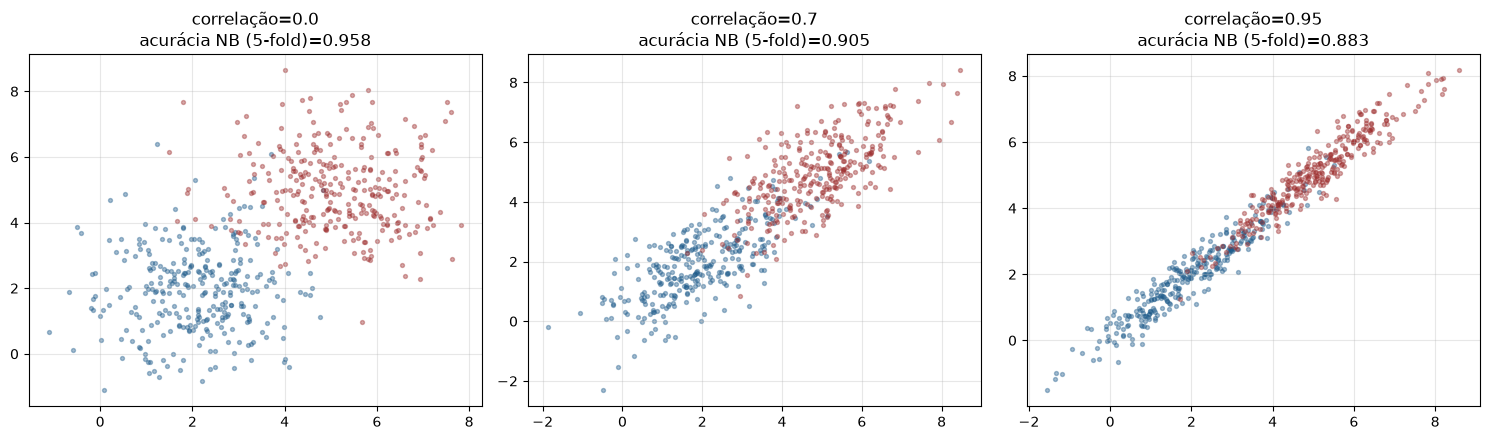

In [3]:
def gera_dados_correlacionados(n, media, correlacao, escala=1.5):
    cov = np.array([[1, correlacao], [correlacao, 1]]) * escala
    return rng.multivariate_normal(media, cov, n)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, corr in zip(axes, [0.0, 0.7, 0.95]):
    X0 = gera_dados_correlacionados(300, [2, 2], corr)
    X1 = gera_dados_correlacionados(300, [5, 5], corr)
    X_corr = np.vstack([X0, X1])
    y_corr = np.concatenate([np.zeros(300), np.ones(300)])

    acc = cross_val_score(GaussianNB(), X_corr, y_corr, cv=5).mean()
    ax.scatter(X0[:, 0], X0[:, 1], s=8, alpha=0.4, color=AZUL)
    ax.scatter(X1[:, 0], X1[:, 1], s=8, alpha=0.4, color=VERMELHO)
    ax.set_title(f"correlação={corr}\nacurácia NB (5-fold)={acc:.3f}")
plt.tight_layout(); plt.show()

**Leitura esperada:** com correlação zero (a suposição do NB é
verdadeira), o desempenho é ótimo. Conforme a correlação cresce, o
desempenho tende a cair — a suposição de independência fica cada vez mais
falsa, e o modelo "vê" a forma elíptica dos dados como se fosse circular
(eixos alinhados aos eixos coordenados), perdendo parte da informação
geométrica real.

## 3. O problema da frequência zero e a suavização de Laplace

In [4]:
# um dataset de texto minúsculo, de propósito, para expor o problema
documentos_treino = [
    "excelente produto recomendo muito",
    "produto excelente e rápida entrega",
    "péssimo produto não recomendo",
    "produto ruim demorou muito para chegar",
]
rotulos_treino = ["positivo", "positivo", "negativo", "negativo"]

vetorizador = CountVectorizer()
X_treino_texto = vetorizador.fit_transform(documentos_treino)
vocabulario = vetorizador.get_feature_names_out()
print(f"vocabulário aprendido: {list(vocabulario)}")

# um documento de teste com uma palavra NUNCA vista com a classe "positivo"
documento_teste = ["produto rápida chegou muito rápida"]
X_teste_texto = vetorizador.transform(documento_teste)

for alpha in [0.0, 1.0]:
    try:
        modelo_nb_texto = MultinomialNB(alpha=alpha).fit(X_treino_texto, rotulos_treino)
        prob = modelo_nb_texto.predict_proba(X_teste_texto)
        print(f"\nalpha={alpha}: probabilidades = {dict(zip(modelo_nb_texto.classes_, prob[0]))}")
    except Exception as exc:
        print(f"\nalpha={alpha}: ERRO — {exc}")

vocabulário aprendido: ['chegar', 'demorou', 'entrega', 'excelente', 'muito', 'não', 'para', 'produto', 'péssimo', 'recomendo', 'ruim', 'rápida']

alpha=0.0: probabilidades = {np.str_('negativo'): np.float64(0.0), np.str_('positivo'): np.float64(1.0)}

alpha=1.0: probabilidades = {np.str_('negativo'): np.float64(0.14584913365614557), np.str_('positivo'): np.float64(0.8541508663438538)}


/home/leo/machine_learning/excercicios-machine-learning/.venv/lib/python3.14/site-packages/sklearn/naive_bayes.py:930: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


> Com `alpha=0` (sem suavização), a palavra "rápida" nunca apareceu nos
> documentos de treino rotulados "negativo" — então $P(\text{"rápida"} |
> \text{negativo}) = 0$ exatamente, e qualquer documento que contenha essa
> palavra recebe probabilidade **zero** para "negativo", não importa quantas
> outras palavras neutras ou ambíguas ele tenha. O modelo fica
> artificialmente overconfident (100% positivo) baseado em uma única
> palavra ausente por acaso de um treino pequeno — não porque a evidência
> realmente aponte com essa certeza. Se a mesma lacuna acontecesse dos dois
> lados ao mesmo tempo para um documento, o `sklearn` não teria nem como
> normalizar as probabilidades (zero dividido por zero). `alpha=1` (Laplace)
> evita os dois problemas garantindo que nenhuma probabilidade condicional
> seja exatamente zero.

## 4. Aplicação real: classificação de sentimento com Multinomial NB

Um dataset sintético maior, com padrões de vocabulário mais realistas.

In [5]:
palavras_positivas = ["ótimo", "excelente", "recomendo", "adorei", "rápido", "qualidade"]
palavras_negativas = ["péssimo", "horrível", "não recomendo", "demorado", "ruim", "quebrado"]
palavras_neutras = ["produto", "entrega", "loja", "comprei", "chegou", "pedido"]


def gera_review(positiva, rng):
    n_palavras = rng.integers(4, 10)
    banco = palavras_positivas if positiva else palavras_negativas
    palavras = list(rng.choice(banco, size=n_palavras // 2)) + \
        list(rng.choice(palavras_neutras, size=n_palavras // 2))
    rng.shuffle(palavras)
    return " ".join(palavras)


n_reviews = 800
reviews = [gera_review(i % 2 == 0, rng) for i in range(n_reviews)]
sentimento = ["positivo" if i % 2 == 0 else "negativo" for i in range(n_reviews)]

X_texto_treino, X_texto_teste, y_texto_treino, y_texto_teste = train_test_split(
    reviews, sentimento, test_size=0.3, random_state=0)

vetorizador_completo = CountVectorizer()
X_vetorizado_treino = vetorizador_completo.fit_transform(X_texto_treino)
X_vetorizado_teste = vetorizador_completo.transform(X_texto_teste)

modelo_texto = MultinomialNB(alpha=1.0).fit(X_vetorizado_treino, y_texto_treino)
pred_texto = modelo_texto.predict(X_vetorizado_teste)
print(f"acurácia na classificação de sentimento: "
      f"{accuracy_score(y_texto_teste, pred_texto):.4f}")
print(f"vocabulário: {X_vetorizado_treino.shape[1]} palavras   "
      f"tempo de treino: praticamente instantâneo, mesmo com mais features "
      f"que exemplos em datasets de texto reais")

acurácia na classificação de sentimento: 1.0000
vocabulário: 18 palavras   tempo de treino: praticamente instantâneo, mesmo com mais features que exemplos em datasets de texto reais


## O que levar deste notebook

- Naive Bayes Gaussiano é literalmente o teorema de Bayes (tema 1) com uma
  verossimilhança gaussiana por feature, assumidas independentes — a
  implementação do zero confirma isso linha por linha.
- A suposição de independência dói mais quanto mais correlacionadas forem
  as features de verdade — mensurável, não só teórico.
- Suavização de Laplace é obrigatória em dados esparsos (texto,
  principalmente): sem ela, uma única combinação não vista no treino pode
  quebrar a previsão inteira.
- Multinomial NB continua sendo um baseline forte e extremamente rápido
  para classificação de texto — o tema 9 aprofunda representações mais
  sofisticadas que constroem sobre essa base.

→ Próximo: o notebook de **exercícios** do módulo.